#**Yelp Dataset**

## **Introduction**:

## Yelp Dataset Overview

The Yelp dataset is a public dataset derived from the Yelp platform, widely used in data science and machine learning projects.

It contains real-world information about:
- **Businesses** (restaurants, shops, services, etc.)
- **User reviews** with ratings and text feedback
- **Users** and their activity profiles
- **Business attributes** such as location, categories, and opening hours

The dataset combines structured data (ratings, categories, metadata) with unstructured text data (reviews), making it suitable for tasks such as recommendation systems, sentiment analysis, and natural language processing.


## Objective

The goal of this notebook is to design and explore the foundations of a robust recommendation system capable of suggesting relevant places or activities to users based on their profiles and preferences.

This work is not focused on building the final model, but rather on conducting an exploratory data analysis (EDA) to understand the structure, patterns, and relationships within the Yelp dataset.

The insights obtained will help identify how a recommendation system could be effectively designed and what optimization strategies could be applied to improve its performance and relevance.

## **I. Downloading the files**

In [ ]:
from google.colab import files
files.upload() #Generate an api key from kaggle and upload it here

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"mamounagadji","key":"b8b1cba0bdee50f47d83e1ae31f24080"}'}

In [ ]:
!kaggle datasets download -d yelp-dataset/yelp-dataset

Dataset URL: https://www.kaggle.com/datasets/yelp-dataset/yelp-dataset
License(s): other
100% 4.07G/4.07G [01:16<00:00, 57.4MB/s]



In [ ]:
!unzip yelp-dataset.zip

Archive:  yelp-dataset.zip
  inflating: Dataset_User_Agreement.pdf  
  inflating: yelp_academic_dataset_business.json  
  inflating: yelp_academic_dataset_checkin.json  
  inflating: yelp_academic_dataset_review.json  
  inflating: yelp_academic_dataset_tip.json  
  inflating: yelp_academic_dataset_user.json  


### **I.1 Exploration**

**Reviews Dataset**

The reviews dataset contains user-generated feedback on businesses. Each row represents a single review written by a user for a specific business.

Main columns:
- **review_id**: Unique identifier for each review  
- **user_id**: Identifier of the user who wrote the review  
- **business_id**: Identifier of the reviewed business  
- **stars**: Rating given by the user (1 to 5)  
- **text**: Full text of the review  
- **date**: Date when the review was posted  
- **useful**: Number of users who marked the review as useful  
- **funny**: Number of users who marked the review as funny  
- **cool**: Number of users who marked the review as cool  


In [ ]:
import pandas as pd

chunks = pd.read_json(
    "yelp_academic_dataset_review.json",
    lines=True,
    chunksize=100000
)

df_reviews = next(chunks)
df_reviews.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


**Business Dataset**

The business dataset contains information about all the establishments listed on Yelp. Each row represents a unique business with its associated metadata.

Main columns:
- **business_id**: Unique identifier for each business  
- **name**: Name of the business  
- **address**: Full address of the business  
- **city**: City where the business is located  
- **state**: State or region  
- **postal_code**: ZIP or postal code  
- **latitude**: Geographic latitude  
- **longitude**: Geographic longitude  
- **stars**: Average rating of the business  
- **review_count**: Number of reviews received  
- **categories**: List of categories describing the business  
- **hours**: Opening hours by day of the week  
- **attributes**: Additional business features (e.g., WiFi, parking, delivery)

This dataset is essential for understanding business characteristics and supporting recommendation and location-based analysis.

In [ ]:

df_business = pd.read_json(
    "yelp_academic_dataset_business.json",
    lines=True
)
df_business.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


In [ ]:
df_business.shape, df_reviews.business_id.nunique()

((150346, 14), 9973)

**Enriching the Reviews Dataset**

We enrich the reviews data by joining it with key business information to add contextual features such as location, categories, and opening hours.

We select only relevant columns from the business dataset, then merge both datasets using `business_id` as the key.

This enriched dataset (`df_reviews_enriched`) combines user feedback with business attributes, enabling deeper analysis and better preparation for the recommendation system.

In [ ]:
df_business_small = df_business[[
    "business_id",
    "name",
    "categories",
    "address",
    "city",
    "latitude",
    "longitude",
    "hours"
]]

df_reviews_enriched = df_reviews.merge(
    df_business_small,
    on="business_id",
    how="left"
)

df_reviews_enriched.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date,name,categories,address,city,latitude,longitude,hours
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11,Turning Point of North Wales,"Restaurants, Breakfast & Brunch, Food, Juice B...",1460 Bethlehem Pike,North Wales,40.210196,-75.223639,"{'Monday': '7:30-15:0', 'Tuesday': '7:30-15:0'..."
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18,Body Cycle Spinning Studio,"Active Life, Cycling Classes, Trainers, Gyms, ...","1923 Chestnut St, 2nd Fl",Philadelphia,39.952103,-75.172753,"{'Monday': '6:30-20:30', 'Tuesday': '6:30-20:3..."
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30,Kettle Restaurant,"Restaurants, Breakfast & Brunch",748 W Starr Pass Blvd,Tucson,32.207233,-110.980864,None
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03,Zaika,"Halal, Pakistani, Restaurants, Indian",2481 Grant Ave,Philadelphia,40.079848,-75.025080,"{'Tuesday': '11:0-21:0', 'Wednesday': '11:0-21..."
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15,Melt,"Sandwiches, Beer, Wine & Spirits, Bars, Food, ...",2549 Banks St,New Orleans,29.962102,-90.087958,"{'Monday': '0:0-0:0', 'Friday': '11:0-17:0', '..."


In [ ]:
df_reviews_enriched["categories_list"] = (
    df_reviews_enriched["categories"]
    .fillna("")
    .apply(lambda x: [c.strip() for c in x.split(", ")] if x else [])
)
all_categories = sorted(
    df_reviews_enriched["categories_list"]
    .explode()
    .dropna()
    .unique()
)

len(all_categories)

980

**Processing Business Categories**

The `categories` column contains multiple labels per business, stored as a single string. We transform this field into a list of individual categories to make it easier to analyze and model.

During exploration, we also observe a high diversity of categories (around 980 unique values). This level of granularity makes direct use difficult for modeling purposes.

To improve interpretability and support recommendation tasks, these micro-categories can later be grouped into higher-level macro categories, reducing complexity and improving generalization.

In [ ]:
df_grouped = df_reviews_enriched.groupby("business_id")["categories_list"].apply(lambda x: set(x.explode())).reset_index()
df_grouped.columns = ["business_id", "micro_categories"]

unique_micro = sorted(
    df_grouped["micro_categories"]
    .explode()
    .dropna()
    .unique()
)

**Category Mapping with LLM**

In the following steps, we use a Groq-based LLM to map micro-categories into predefined macro-categories defined in the prompt.

The model is used to generate a consistent taxonomy that groups similar business categories into higher-level classes.

The resulting mapping is then applied to the previously enriched dataset to replace micro-categories with their corresponding macro-categories.

In [ ]:
pip install langchain

In [ ]:
pip install -U langchain-groq

In [ ]:
import getpass
import os
from langchain_groq import ChatGroq


token=getpass.getpass("Enter your Groq API token: ")
os.environ["GROQ_API_KEY"] = token

model = ChatGroq(
    model="llama-3.1-8b-instant",  # ou autre modèle disponible
    temperature=0.4
)

Enter your Groq API token: ··········


In [ ]:
import json
def map_to_macro(micro_list):
    prompt = f"""
You are a strict JSON generator.

Task:
Map each micro-category to one macro category.

RULES:
- Output ONLY valid JSON
- No explanations
- No text before or after
- No markdown
- Keys = micro-category
- Values = macro-category

Allowed macro categories:
Food & Beverage, Health & Medical, Beauty & Wellness, Automotive,
Education, Entertainment & Leisure, Travel & Hospitality,
Retail & Shopping, Professional Services, Home Services,
Animals & Pets, Public Services, Real Estate, Other

Input:
{micro_list}

Output example:
{{
  "Sushi Bars": "Food & Beverage"
}}
"""
    response = model.invoke(prompt).content
    return json.loads(response)

In [ ]:
from tqdm import tqdm

mapping = {}

for micro in tqdm(unique_micro):
    try:
        macro_dict = map_to_macro([micro])
        mapping.update(macro_dict)
    except:
        mapping[micro] = "Other"

100%|██████████| 980/980 [34:49<00:00,  2.13s/it]


In [ ]:
 df_grouped["macro_categories"] = df_grouped["micro_categories"].apply(
    lambda x: list(dict.fromkeys(mapping.get(i, "Other") for i in x))
)

In [ ]:
df_grouped.to_parquet("categories_mapping.parquet", index=False)
files.download("categories_mapping.parquet")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
i=np.random.randint(1,len(df_grouped))
df_grouped.iloc[i]

,9259
business_id,vULxbye7rxpW1UHUWbpcBg
micro_categories,"{Men's Hair Salons, Skin Care, Hair Salons, Ha..."
macro_categories,[Beauty & Wellness]


In [ ]:
df_final = df_reviews_enriched.merge(
    df_grouped[["business_id", "macro_categories"]],
    on="business_id",
    how="left"
)

df_final = df_final.rename(columns={"categories": "description"})

df_final = df_final.drop(columns=["categories_list"])

Final Dataset Preparation

We now obtain the final dataset (`df_final`) after applying the macro-category mapping and completing the enrichment process.

The original `categories` column is renamed to `description`, as it represents a textual description of the business rather than a structured feature.

In [ ]:
df_final.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date,name,description,address,city,latitude,longitude,hours,macro_categories
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11,Turning Point of North Wales,"Restaurants, Breakfast & Brunch, Food, Juice B...",1460 Bethlehem Pike,North Wales,40.210196,-75.223639,"{'Monday': '7:30-15:0', 'Tuesday': '7:30-15:0'...","[Other, Food & Beverage]"
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18,Body Cycle Spinning Studio,"Active Life, Cycling Classes, Trainers, Gyms, ...","1923 Chestnut St, 2nd Fl",Philadelphia,39.952103,-75.172753,"{'Monday': '6:30-20:30', 'Tuesday': '6:30-20:3...","[Health & Medical, Fitness Classes, Retail & S..."
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30,Kettle Restaurant,"Restaurants, Breakfast & Brunch",748 W Starr Pass Blvd,Tucson,32.207233,-110.980864,None,[Food & Beverage]
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03,Zaika,"Halal, Pakistani, Restaurants, Indian",2481 Grant Ave,Philadelphia,40.079848,-75.025080,"{'Tuesday': '11:0-21:0', 'Wednesday': '11:0-21...",[Food & Beverage]
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15,Melt,"Sandwiches, Beer, Wine & Spirits, Bars, Food, ...",2549 Banks St,New Orleans,29.962102,-90.087958,"{'Monday': '0:0-0:0', 'Friday': '11:0-17:0', '...","[Other, Food & Beverage, Entertainment & Leisure]"


In [ ]:
df_final.to_parquet("Yelp_dataset_reviews_enriched.parquet", index=False)

In [ ]:
from google.colab import files
files.download("Yelp_dataset_reviews_enriched.parquet")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**-----------------------------------------------------------------------------------------------------------------------------**

In [ ]:
import pandas as pd
df_final = pd.read_parquet("Yelp_dataset_reviews_enriched.parquet")


In [ ]:
df_final.isna().sum()

,0
review_id,0
user_id,0
business_id,0
stars,0
useful,0
funny,0
cool,0
text,0
date,0
name,0


## **II. Food Subset (`df_food`)**

To focus the analysis on a specific domain, we extract a subset of the dataset containing only food-related businesses. This subset includes restaurants, cafes, bars, and other food & beverage establishments.

The resulting dataset (`df_food`) will be used for building and evaluating the recommendation system within a constrained and consistent domain.

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
cat_df = pd.DataFrame(mlb.fit_transform(df_final['macro_categories'].fillna('[]')),columns=mlb.classes_, index=df_final.index)
cat_df = pd.concat([df_final.drop(columns=['macro_categories']), cat_df], axis=1)


df_food=cat_df[cat_df['Food & Beverage']==1]
df_food.head()



,review_id,user_id,business_id,stars,useful,funny,cool,text,date,name,...,Health & Medical,Home Services,Other,Professional Services,Public Services,Real Estate,Retail & Shopping,Transportation,Travel & Hospitality,Wedding & Bridal Services
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11,Turning Point of North Wales,...,0,0,1,0,0,0,0,0,0,0
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30,Kettle Restaurant,...,0,0,0,0,0,0,0,0,0,0
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03,Zaika,...,0,0,0,0,0,0,0,0,0,0
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15,Melt,...,0,0,1,0,0,0,0,0,0,0
5,JrIxlS1TzJ-iCu79ul40cQ,eUta8W_HdHMXPzLBBZhL1A,04UD14gamNjLY0IDYVhHJg,1,1,2,1,I am a long term frequent customer of this est...,2015-09-23 23:10:31,Dmitri's,...,0,0,0,0,0,0,0,0,0,0


### II.1 Popularity-Based Recommendation System

We build a simple recommendation system based on business popularity using a weighted rating approach inspired by the IMDb scoring formula.

The idea is to balance:
- the average rating of a business
- the number of reviews it has received
- the global average rating across all businesses

This prevents small businesses with few high ratings from being over-ranked compared to more reliable and widely reviewed businesses.

We define the score as follows:

- **r**: average rating of the business  
- **v**: number of reviews  
- **c**: global average rating  
- **m**: minimum number of reviews required for full confidence adjustment  




In [ ]:
df_business_score = df_food.groupby("business_id").agg({
    "stars": "mean",          # r
    "review_id": "count"      # v
}).rename(columns={
    "stars": "mean",
    "review_id": "reviews_count"
}).reset_index()

m = 500
c = df_food.stars.mean()

def imdb_score(x):
    v = x["reviews_count"]
    r = x["mean"]
    return (v/(v+m) * r) + (m/(m+v) * c)

df_business_score["score"] = df_business_score.apply(imdb_score, axis=1)
df_business_score = df_business_score.sort_values("score", ascending=False)
df_business_score=pd.merge(df_business_score,df_food[["business_id","name"]].drop_duplicates(),on='business_id', how='left')
df_business_score.head()

,business_id,mean,reviews_count,score,name
0,vN6v8m4DO45Z4pp8yxxF_w,4.457921,404,4.113902,Surrey's Café & Juice Bar
1,_aKr7POnacW_VizRKBpCiA,4.811111,180,4.094069,Blues City Deli
2,UCMSWPqzXjd7QHq7v8PJjQ,4.445748,341,4.083195,Prep & Pastry
3,8uF-bhJFgT4Tn6DTb27viA,4.419178,365,4.082043,District Donuts Sliders Brew
4,2KIDQyTh-HzLxOUEDqtDBg,4.643519,216,4.079563,Mazzaro's Italian Market


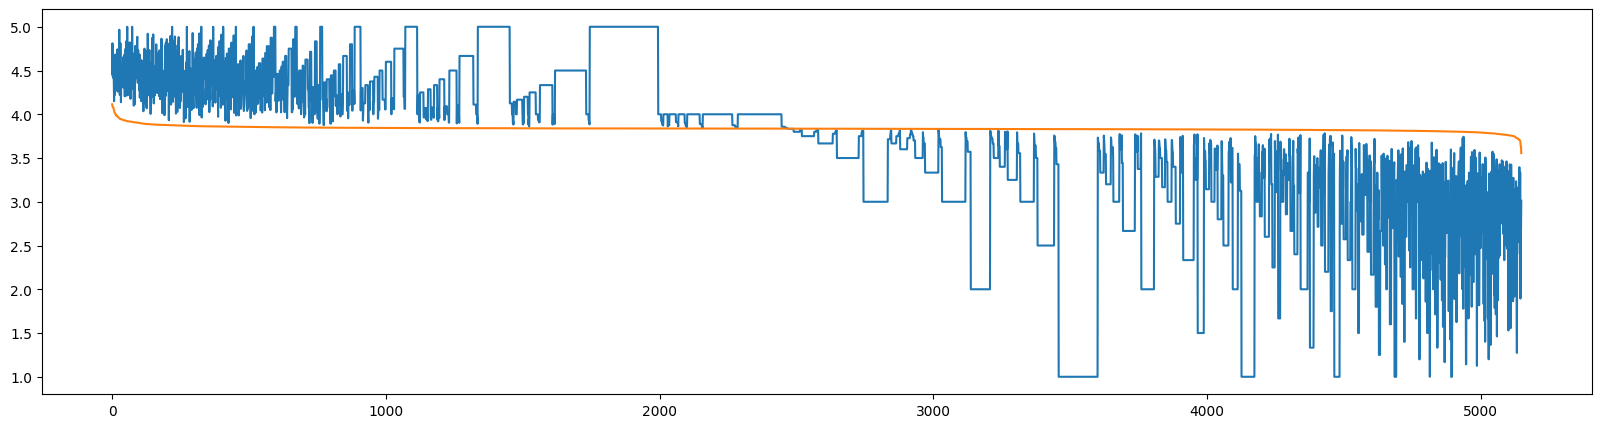

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20,5))
plt.plot(range(len(df_business_score)),df_business_score["mean"])
plt.plot(range(len(df_business_score)),df_business_score["score"])

((5149, 5), (79968, 36))

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer


import pandas as pd


### **II.2 Content-Based Recommendation System**

We build a content-based recommendation system using multiple signals to measure similarity between food businesses.

Each business is represented using three main types of features:
- **Description features**: vectorized textual information using a vectorization method (e.g., TF-IDF or CountVectorizer)
- **Geographical features**: latitude and longitude to capture spatial proximity





### **II.2.a With TF-IDF Vectorizer**

**Vectorization**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
import pandas as pd


df_food_business=df_food.drop_duplicates(subset='business_id')

vectorizer = TfidfVectorizer(max_features=500)

X_text_tfidf = vectorizer.fit_transform(df_food_business["description"])


**calculation of similarity matrices**

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

text_sim_tfidf = cosine_similarity(X_text_tfidf)

**Geographic Distance Calculation**

We use the Haversine formula to compute the distance between two businesses based on their latitude and longitude.

This function returns the distance in kilometers and allows us to incorporate spatial proximity into the recommendation system.

In [ ]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

**Recommendation Strategy**

To generate recommendations, we use a similarity matrix computed from business description.

For a given business:
- we retrieve its similarity scores with all other businesses
- we compute geographic distance using latitude and longitude with haversine function
- we prioritize nearby businesses within a defined distance threshold (here 15 Km)


In [ ]:
df_food_business = df_food_business.reset_index(drop=True)

indices = pd.Series(
    df_food_business.index,
    index=df_food_business["business_id"]
)

def get_reco(business_id, sim_matrix, top_n=5, city_threshold=15):
    idx = indices[business_id]

    sims = sim_matrix[idx]

    lat1 = df_food_business.iloc[idx]["latitude"]
    lon1 = df_food_business.iloc[idx]["longitude"]

    lat2 = df_food_business["latitude"].values
    lon2 = df_food_business["longitude"].values

    dists = haversine(lat1, lon1, lat2, lon2)

    same_city_mask = dists <= city_threshold

    same_city_idx = np.where(same_city_mask)[0]
    outside_idx = np.where(~same_city_mask)[0]

    same_sorted = same_city_idx[np.argsort(sims[same_city_idx])[::-1]]
    outside_sorted = outside_idx[np.argsort(sims[outside_idx])[::-1]]

    final_idx = np.concatenate([same_sorted, outside_sorted])
    final_idx = final_idx[final_idx != idx]

    recos = df_food_business.iloc[final_idx[:top_n]]

    return list(recos["business_id"].unique())

In [ ]:
def show_reco(f,business_id,sim):
  orig = df_food_business[df_food_business["business_id"]==business_id].iloc[0]
  print(
      f"Original: {orig['name']}: {orig['description']}, "
  )

  j = 0

  for reco in f(business_id, sim):
      row = df_food_business[df_food_business["business_id"] == reco].iloc[0]

      dist = haversine(
          orig["latitude"], orig["longitude"],
          row["latitude"], row["longitude"]
      )

      print(
          f"{j+1}. {row['name']}: "
          f"{row['description']}, "
          f"distance: {round(dist, 2)} km"
      )

      j += 1

 **Results**

In [ ]:
i = np.random.randint(len(df_food_business))

business_id = df_food_business["business_id"].iloc[i]
show_reco(get_reco,business_id, text_sim_tfidf)

Original: Dickey's Barbecue Pit: Restaurants, Chicken Wings, Barbeque, Southern, American (Traditional), 
1. LongHorn Steakhouse: Steakhouses, American (Traditional), Barbeque, Restaurants, distance: 0.51 km
2. Preachers BBQ: Barbeque, Restaurants, distance: 8.63 km
3. Big Tim's BBQ: Barbeque, Restaurants, distance: 5.38 km
4. Hooters: Restaurants, American (New), Sports Bars, Chicken Wings, American (Traditional), Nightlife, Burgers, Bars, distance: 0.85 km
5. Pizza Hut: Chicken Wings, Restaurants, Pizza, Italian, distance: 8.86 km


### **II.2.b with a transformer**

In [ ]:
pip install sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

**Clean texts**

In [ ]:
def clean_text(t):
    return " ".join(
        sorted(set(
            w.strip().lower()
            for w in t.split(",")
            if w.strip()
        ))
    )

**creating embeddings**

In [ ]:
texts = df_food_business["description"].fillna("").apply(clean_text).tolist()

X_text = model.encode(
    texts,
    normalize_embeddings=True,
    show_progress_bar=True
)

Batches:   0%|          | 0/161 [00:00<?, ?it/s]

**calculation of similarity matrices**

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

text_sim = cosine_similarity(X_text)

**Results**

In [ ]:
i = np.random.randint(len(df_food_business))

business_id = df_food_business["business_id"].iloc[i]

show_reco(get_reco,business_id, text_sim)

Original: Beawon: Korean, Restaurants, Chinese, 
1. Jjang Ga Nae: Korean, Chinese, Restaurants, distance: 4.44 km
2. Eden Korean Restaurant: Restaurants, Korean, distance: 1.27 km
3. No 1 Chinese Food: Restaurants, Chinese, distance: 8.19 km
4. Yummy Yummy: Restaurants, Chinese, distance: 9.87 km
5. Great Taste Chinese Food: Chinese, Restaurants, distance: 4.44 km


**Comparison**

In [ ]:
i = np.random.randint(len(df_food_business))

business_id = df_food_business["business_id"].iloc[i]
print("===========")
print("TF-IDF Method")
show_reco(get_reco,business_id, text_sim)
print("===========")
print("Transformer Method")
show_reco(get_reco,business_id, text_sim_tfidf)

TF-IDF Method
Original: Rush Bowls: Food, Restaurants, Acai Bowls, Fruits & Veggies, Specialty Food, Juice Bars & Smoothies, Vegetarian, 
1. E+ROSE Wellness Cafe of Brentwood: Food, Juice Bars & Smoothies, Vegan, Restaurants, Acai Bowls, distance: 12.65 km
2. The Urban Juicer: Breakfast & Brunch, Food, Salad, Juice Bars & Smoothies, Acai Bowls, Restaurants, Coffee & Tea, distance: 4.33 km
3. Lynne Lorraine's: Vegan, Sandwiches, Juice Bars & Smoothies, Restaurants, Specialty Food, Food, Fruits & Veggies, distance: 4.01 km
4. Nectar Urban Cantina: Coffee & Tea, New Mexican Cuisine, Restaurants, Tacos, Acai Bowls, Food, Nightlife, Mexican, Bars, Juice Bars & Smoothies, distance: 9.69 km
5. Juice Bar - Hillsboro Village: Restaurants, Food, Vegetarian, Juice Bars & Smoothies, Vegan, distance: 2.25 km
Transformer Method
Original: Rush Bowls: Food, Restaurants, Acai Bowls, Fruits & Veggies, Specialty Food, Juice Bars & Smoothies, Vegetarian, 
1. Lynne Lorraine's: Vegan, Sandwiches, Juice Bars

 **Best method: Transformer-based**

It provides:
- better semantic understanding
- improved relevance in complex cases
- more meaningful diversity in recommendations

TF-IDF remains a strong baseline but is less expressive for real-world recommendation quality.

## Multi-Example Recommendation Comparison

The code below generates multiple recommendation examples across different businesses using both Methods.

The results are exported into a PDF file for easier inspection and structured comparison.

It provides a practical way to assess and compare the performance of both approaches on multiple real cases.

In [ ]:
pip install reportlab

In [ ]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet

from random import sample

styles = getSampleStyleSheet()

pdf = SimpleDocTemplate("comparison_AB.pdf")

content = []

# choisir plusieurs i
inds = sample(range(len(df_food_business)), k=20)  # ajuste k

for i in inds:

    business_id = df_food_business["business_id"].iloc[i]
    orig = df_food_business[df_food_business["business_id"] == business_id].iloc[0]
    score=df_business_score[df_business_score["business_id"]==business_id].iloc[0]["score"]
    content.append(Paragraph(f"<b>Original:</b> {orig['name']} : {orig['description']},score:{round(score,2)}", styles["Normal"]))
    content.append(Spacer(1, 10))


    content.append(Paragraph("<b>Méthode A</b>", styles["Heading3"]))

    j = 1
    for reco in get_reco(business_id, text_sim_tfidf):

        row = df_food_business[df_food_business["business_id"] == reco].iloc[0]
        score=df_business_score[df_business_score["business_id"]==reco].iloc[0]["score"]
        dist = haversine(
            orig["latitude"], orig["longitude"],
            row["latitude"], row["longitude"]
        )

        text = f"{j}. {row['name']} : {row['description']} (distance: {round(dist,2)} km, score:{round(score,2)})"
        content.append(Paragraph(text, styles["Normal"]))
        j += 1

    content.append(Spacer(1, 12))


    content.append(Paragraph("<b>Méthode B</b>", styles["Heading3"]))

    j = 1
    for reco in get_reco(business_id, text_sim):

        row = df_food_business[df_food_business["business_id"] == reco].iloc[0]
        score=df_business_score[df_business_score["business_id"]==reco].iloc[0]["score"]
        dist = haversine(
            orig["latitude"], orig["longitude"],
            row["latitude"], row["longitude"]
        )

        text = f"{j}. {row['name']} : {row['description']} (distance: {round(dist,2)} km, score:{round(score,2)})"
        content.append(Paragraph(text, styles["Normal"]))
        j += 1

    content.append(Spacer(1, 25))


pdf.build(content)